In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from AnalyzeDataset import AnalyzeDataset


## Table Of Contents:  
> Load the data  
> Initialize the Class: AD = AnalyzeDataset()    
> Call Fit: AD.fit_full_dataset_analysis(df) 
> Produce a DataFrame to View Fit Results: AD.column_relationships_df() 
> Plotting Options  
  

### Load data  

In [2]:
import Consumer_Habits_file_loader
from Consumer_Habits_file_loader import load_consumer_habits
df = load_consumer_habits('shopping_behavior_updated.csv')

\\wsl.localhost\Ubuntu\home\lelandmesford\Projects\Consumer_Habits\utils\Consumer_Habits_file_loader.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Male']=df['Gender'].replace({'Male':1,'Female':0}).astype('object')


UnboundLocalError: cannot access local variable 'num_num_pairs' where it is not associated with a value

# Initialize the Class with Default Parameters

In [ ]:
# params: 
kruskal_assumption_check_params = {'levene_alpha':0.01,'ks_alpha':0.01,'return_pseudo':True, 'pseudo_test_max_global_ties_ratio': 0.7,
                                    'full_pseudo':False,'dropna':True, 'n_jobs':-8, 'guesstimate':{'rej_max_pct_in_group':0.2,
                                    'max_num_outlier_all_reject':3, 'max_pct_reject_total':0.2}}
anova_assumption_check_params   = {'normality_alpha':0.01, 'homogeneity_alpha':0.01, 'min_n':5, 'iqr_multiplier':2, 'dropna':True} 
chi2_assumption_check_params    = {'dropna':True}
supercat_subcat_params          = {'max_evidence':0.2,  'isolate_super_subs':False }
multivariate_params             = {'max_n_combination_size':3, 'max_n_combinations':50_000,  'min_combo_size':2}
multivariate_concatenation_delimiter = "_|&|_" 
numnum_meth_alpha_above_instructions = [('pearson',0.6,None),('spearman',0.6,None),('kendall',0.6,None)]
numcat_meth_alpha_above_instructions = [('kruskal',0.05,None),('anova',0.05,None)]
catcat_meth_alpha_above_instructions = [('chi2',0.05,None)] 
good_of_fit_uniform_test_instrucions = (0.05,None) 
normal_test_instructions             = (0.05,None) 


AD = AnalyzeDataset(multivariate_params = multivariate_params,
                        kruskal_assumption_check_params=kruskal_assumption_check_params,
                        anova_assumption_check_params = anova_assumption_check_params,
                        chi2_assumption_check_params = chi2_assumption_check_params,
                        supercat_subcat_params = supercat_subcat_params,
                        multivariate_concatenation_delimiter = multivariate_concatenation_delimiter,
                        numnum_meth_alpha_above_instructions=numnum_meth_alpha_above_instructions,
                        numcat_meth_alpha_above_instructions=numcat_meth_alpha_above_instructions,
                        catcat_meth_alpha_above_instructions=catcat_meth_alpha_above_instructions,
                        good_of_fit_uniform_test_instrucions=good_of_fit_uniform_test_instrucions,
                        normal_test_instructions=normal_test_instructions
                        )

              
                          
                          

# Fit statistically significant differences  
where fit_mulitvariates==True can have a big impact on compute time.  

In [ ]:
AD.fit_full_dataset_analysis(df,  
                            numeric_columns=None,         # None for autodetect
                            categoric_columns=None,       # None for autodetect
                            numeric_target=None,          # None to compute all numeric varaibles as targets
                            categoric_target=None,        # None to compute all categoric varaibles as targets                          
                            fit_good_of_fit=True,         # instruct to test categoric variables for uniform distribution
                            fit_normal=True,
                            fit_multivariates=False,       # instruct to test multivariate significance
                            fit_supercat_subcats=True)    # test for supercategories with subcategories that partition other variables

\\wsl.localhost\Ubuntu\home\lelandmesford\Projects\Consumer_Habits\utils\AnalyzeDataset.py:1106: UserWarning: 
No combinations considered for Total Days Of Patronage_Binned. 
Population_size == 0, but minimum combo size is 2
  warn(f"\nNo combinations considered for {target.title()}. \nPopulation_size == {population_size}, but minimum combo size is {min_combo_size}")


# A dataframe to summarize fit results based on rejected nulls and correlations above thresholds

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth',None)
AD.column_relationships_df(targets=None)

Where 'MaxLenComboComparedTo' can vary depending on compute limits and number of possible combinations in combo sizes.
'FeatureColum(s)' is a combination or single column that shares a significant relationship according to the test(s).
'Test(s)' lists the test(s) used. If the testname is followed by a colon, that signals whether assumptions were met for that specifit test.


FeatureColum(s)  \
Target                              Type      Distrubition           MaxLenCombosComparedTo                                                                               
Promo Code Used                     categoric reject_uniform         3                                                                                 Discount Applied   
                                                                     3                                                                              Subscription Status   
                                                                     3                                                                                             Male   
                                                                     3                                                   [Frequency of Purchases, Payment Method, Size]   
Season                              categoric fail_to_reject_uniform 3                                                                            Purchase Amount (USD)   
                                                                     3                                                                     Purchase Amount (USD)_Binned   
                                                                     3                                                        [Purchase Amount (USD)_Ordinalized, Size]   
                                                                     3                                                                  [Payment Method, Shipping Type]   
                                                                     3                                                                       [Category, Payment Method]   
Age                                 numeric   reject_normal          3                                         [Frequency of Purchases, Previous Purchases_Ordinalized]   
                                                                     3                                                               [Color, Review Rating_Ordinalized]   
                                                                     3                       [Item Purchased, Subscription Status, Total Days of Patronage_Ordinalized]   
                                                                     3                             [Location, Subscription Status, Total Days of Patronage_Ordinalized]   
                                                                     3                             [Payment Method, Shipping Type, Total Days of Patronage_Ordinalized]   
                                                                     3                                  [Category, Payment Method, Total Days of Patronage_Ordinalized]   
                                                                     3                                                                  [Location, Male, Shipping Type]   
Previous Purchases_Binned           numeric   reject_normal          3                                                                               Previous Purchases   
                                                                     3                                                              Total Days of Patronage_Ordinalized   
                                                                     3                                                                                   Item Purchased   
                                                                     3                                                                                             Male   
                                                                     3                                                                   Previous Purchases_Ordinalized   
                                                                     3                                                                   [Frequency of Purchases, Size]   
                                                

# Low Level Details

### Access Results Globally for the Entire Dataset  

In [ ]:
print('Categorical Columns that Rejected the Goodness-of-Fit Test for a Uniform Distribution'.upper())
print('          ',AD.reject_null_good_of_fit)
print('Categorical that Failed to Reject Uniform Distribution'.upper())
print('          ',AD.fail_to_reject_null_good_of_fit)
print('Numerical Columns that Rejected a test for Normal Distribution'.upper())
print('          ',AD.reject_null_normal)
print('Numerical that Failed to Reject a test for a Normal Distribution'.upper())
print('          ',AD.fail_to_reject_null_normal)
print('Numeric-Numeric Bivariates with Correlaiton Above the Threshold'.upper())
print('          ',AD.above_threshold_corr_numnum) 
print('Numeric-Numeric Bivariates with Correlaiton Below the Threshold'.upper())
print('          ',AD.below_threshold_corr_numnum)
print('Numeric-Categoric Bivariates that Rejected the Null Hypothesis'.upper())
print('          ',AD.reject_null_numcat)
print('Numeric-Categoric Bivariates that Failed to Reject the Null Hypothesis'.upper())
print('          ',AD.fail_to_reject_null_numcat)
print('Categoric-Categoric Bivariates that Rejected the Null Hypothesis'.upper())
print('          ',AD.reject_null_catcat)
print('Categoric-Categoric Bivariates that Failed to Reject the Null Hypothesis'.upper())
print('          ',AD.fail_to_reject_null_catcat)
print('Supercategory variables that partition another variable into Subcategories'.upper())
print('          ',AD.supercategory_subcategory_pairs)
print('Multivariat variables. Target and target type followed by a combination of categoric variables. Then the test type.'.upper())
print('          ',AD.significant_multivariate_combinations)
print('Univariate and Bivariate cases where test assumptions were not met.'.upper())
for k,v in AD.assumptions_not_met.items():
    print('          ',k,':  ',v)

CATEGORICAL COLUMNS THAT REJECTED THE GOODNESS-OF-FIT TEST FOR A UNIFORM DISTRIBUTION
           {'Promo Code Used', 'Discount Applied', 'Total Days of Patronage_Ordinalized', 'Size', 'Review Rating_Ordinalized', 'Subscription Status', 'Male', 'Category', 'Previous Purchases_Ordinalized'}
CATEGORICAL THAT FAILED TO REJECT UNIFORM DISTRIBUTION
           {'Frequency of Purchases', 'Season', 'Color', 'Item Purchased', 'Location', 'Payment Method', 'Shipping Type', 'Purchase Amount (USD)_Ordinalized'}
NUMERICAL COLUMNS THAT REJECTED A TEST FOR NORMAL DISTRIBUTION
           {'Purchase Amount (USD)_Binned', 'Age', 'Review Rating_Binned', 'Previous Purchases_Binned', 'Total Days of Patronage_Binned', 'Review Rating', 'Previous Purchases', 'Purchase Amount (USD)', 'Total Days of Patronage'}
NUMERICAL THAT FAILED TO REJECT A TEST FOR A NORMAL DISTRIBUTION
           set()
NUMERIC-NUMERIC BIVARIATES WITH CORRELAITON ABOVE THE THRESHOLD
           [['Purchase Amount (USD)', 'Purchase Amount (US

## ====================================================================================================   
# High Level Visuals   
## ====================================================================================================  

## Two Plot Functions W/ Dynamic Output

In [ ]:
# parameters:
cat_univar_params =         {'proportions':False,'n_wide':(6,40,4),
                             'super_title':"Univariate Categorical Variables - Reject Good-Of-Fit for Uniform"}
catcat_bivar_params =       {'n_wide':(6,40,5),'stacked_bars_when_max_bars_is_exceeded':True,'sorted':False,
                             'super_title':"Categoric-To-Categoric Bivariates - Reject Null"}
numnum_bivar_params =       {'plot_type':'joint','linreg':True,'plot_type_kwargs':None,'linreg_kwargs':None,
                             'super_title':'Numeric Bivariates With Significant Correlation(s)'}
numcat_bivar_params =       {'plot_type':'boxen', 'n_wide':(6,40,8), 
                             'super_title':'Numeric-to-Categoric Bivariates  - Reject Null' }
super_subcat_pairs_params = {'row_height':2,'cols_per_row':3,'y_tick_fontsize':12,
                             'super_title':"Supercategory-Subcategory - One Categoric Variable Partitions Another"} 
num_univar_params =         {'kde':None,'proportions':False,'n_wide':(6,40,4),
                             'super_title':"Univariate Numerical Variables - Reject Normal Distribution",
                             'force_significant_bin_edges':None,  'minimize_significant_bins':None, 'include_multivariate':True} 



### Plot by input pairs, infer rejected null and correlation above threshold, or set to False   

Plot Categoric Univariate is set to False
Plot Numeric Univariate is set to False
Plot Bivariate Categoric-Categoric is set to False
Plot Bivariate Numeric-Numeric is set to False


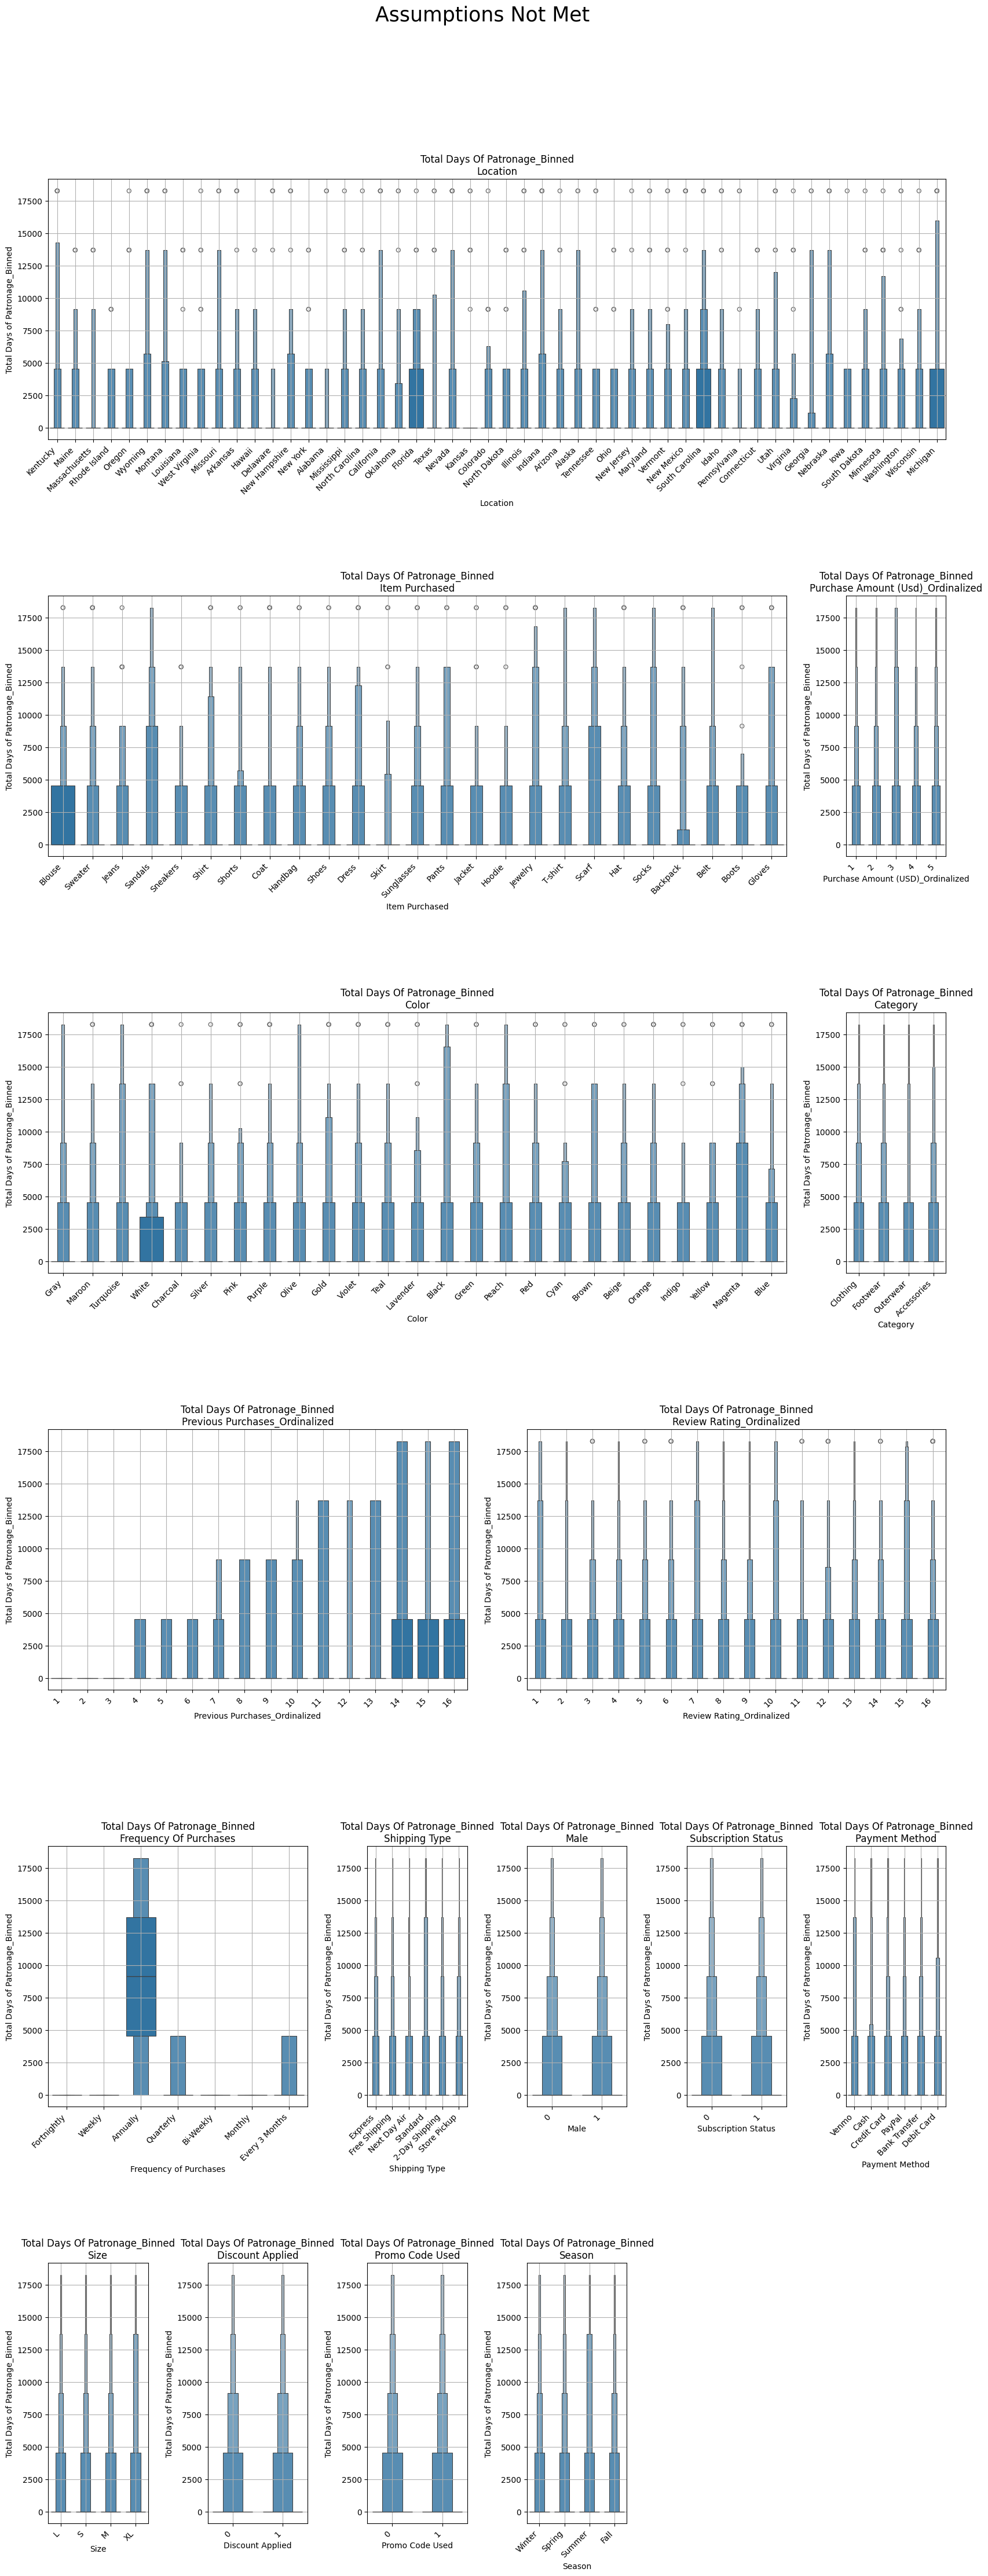

Plot Supercategory-Subcategory Partitions is set to False


In [ ]:
# plots based on what has been fit globally
AD.produce_all_plots(df,
                    cat_univar=False,   # None or True indicate variables should be derived from fit results. Otherwise input list or str
                    num_univar=False, 
                    catcat_bivar=False,
                    numnum_bivar=False,
                    numcat_bivar=AD.assumptions_not_met['numcat'],    # can manually input valus. such as: AD.assumptions_not_met['numcat']
                    super_subcat_pairs=False,
                    cat_univar_params = cat_univar_params,
                    catcat_bivar_params = catcat_bivar_params,
                    numnum_bivar_params = numnum_bivar_params,
                    numcat_bivar_params = {'super_title':"Assumptions Not Met"}, # numcat_bivar_params,
                    super_subcat_pairs_params = super_subcat_pairs_params,
                    num_univar_params = num_univar_params
                  )

### Plot individual targets based on reject null and correlation above threshold  
### Set how targets are output with the targets_share_plots perameter

= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 
SIGNIFICANT VISUALIZATIONS FOR Review Rating
Non-Value Plots will Automatically be set to False
Plot Categoric Univariate is set to False


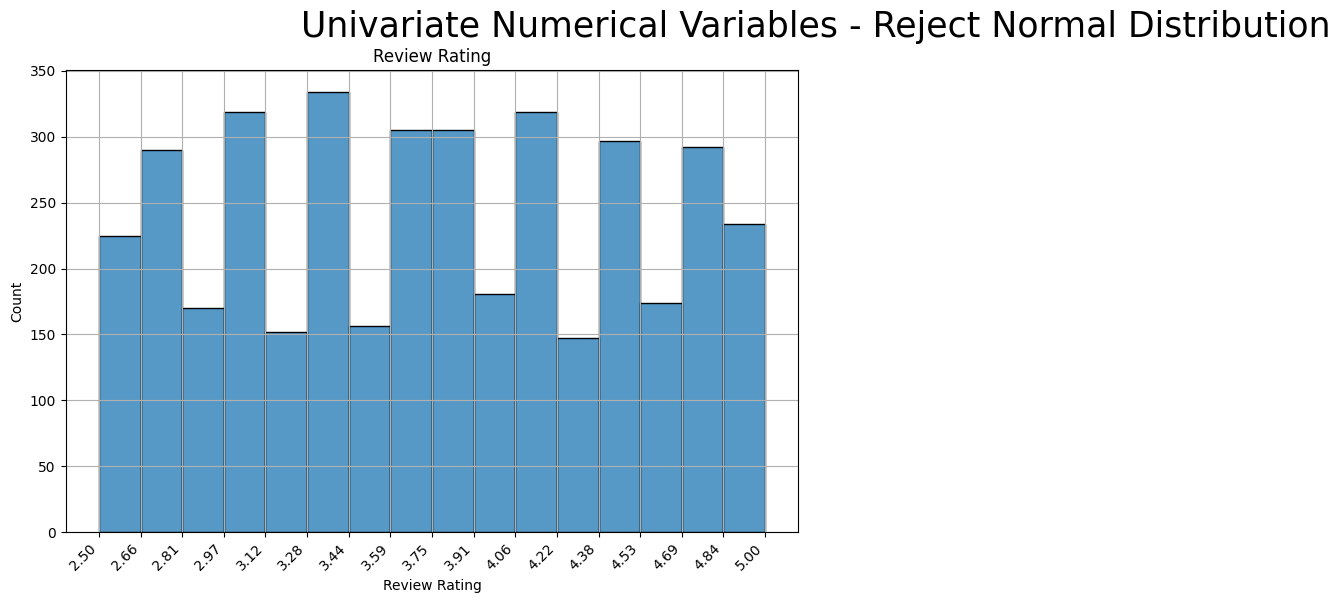

Plot Bivariate Categoric-Categoric is set to False


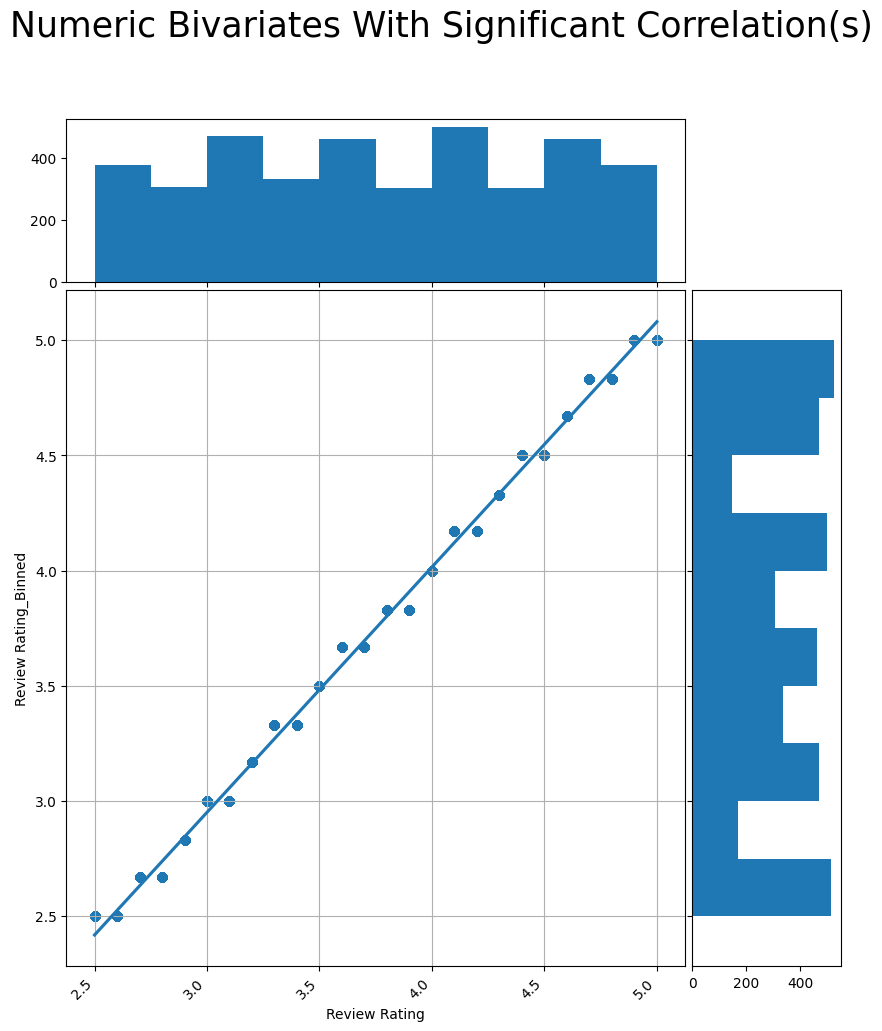

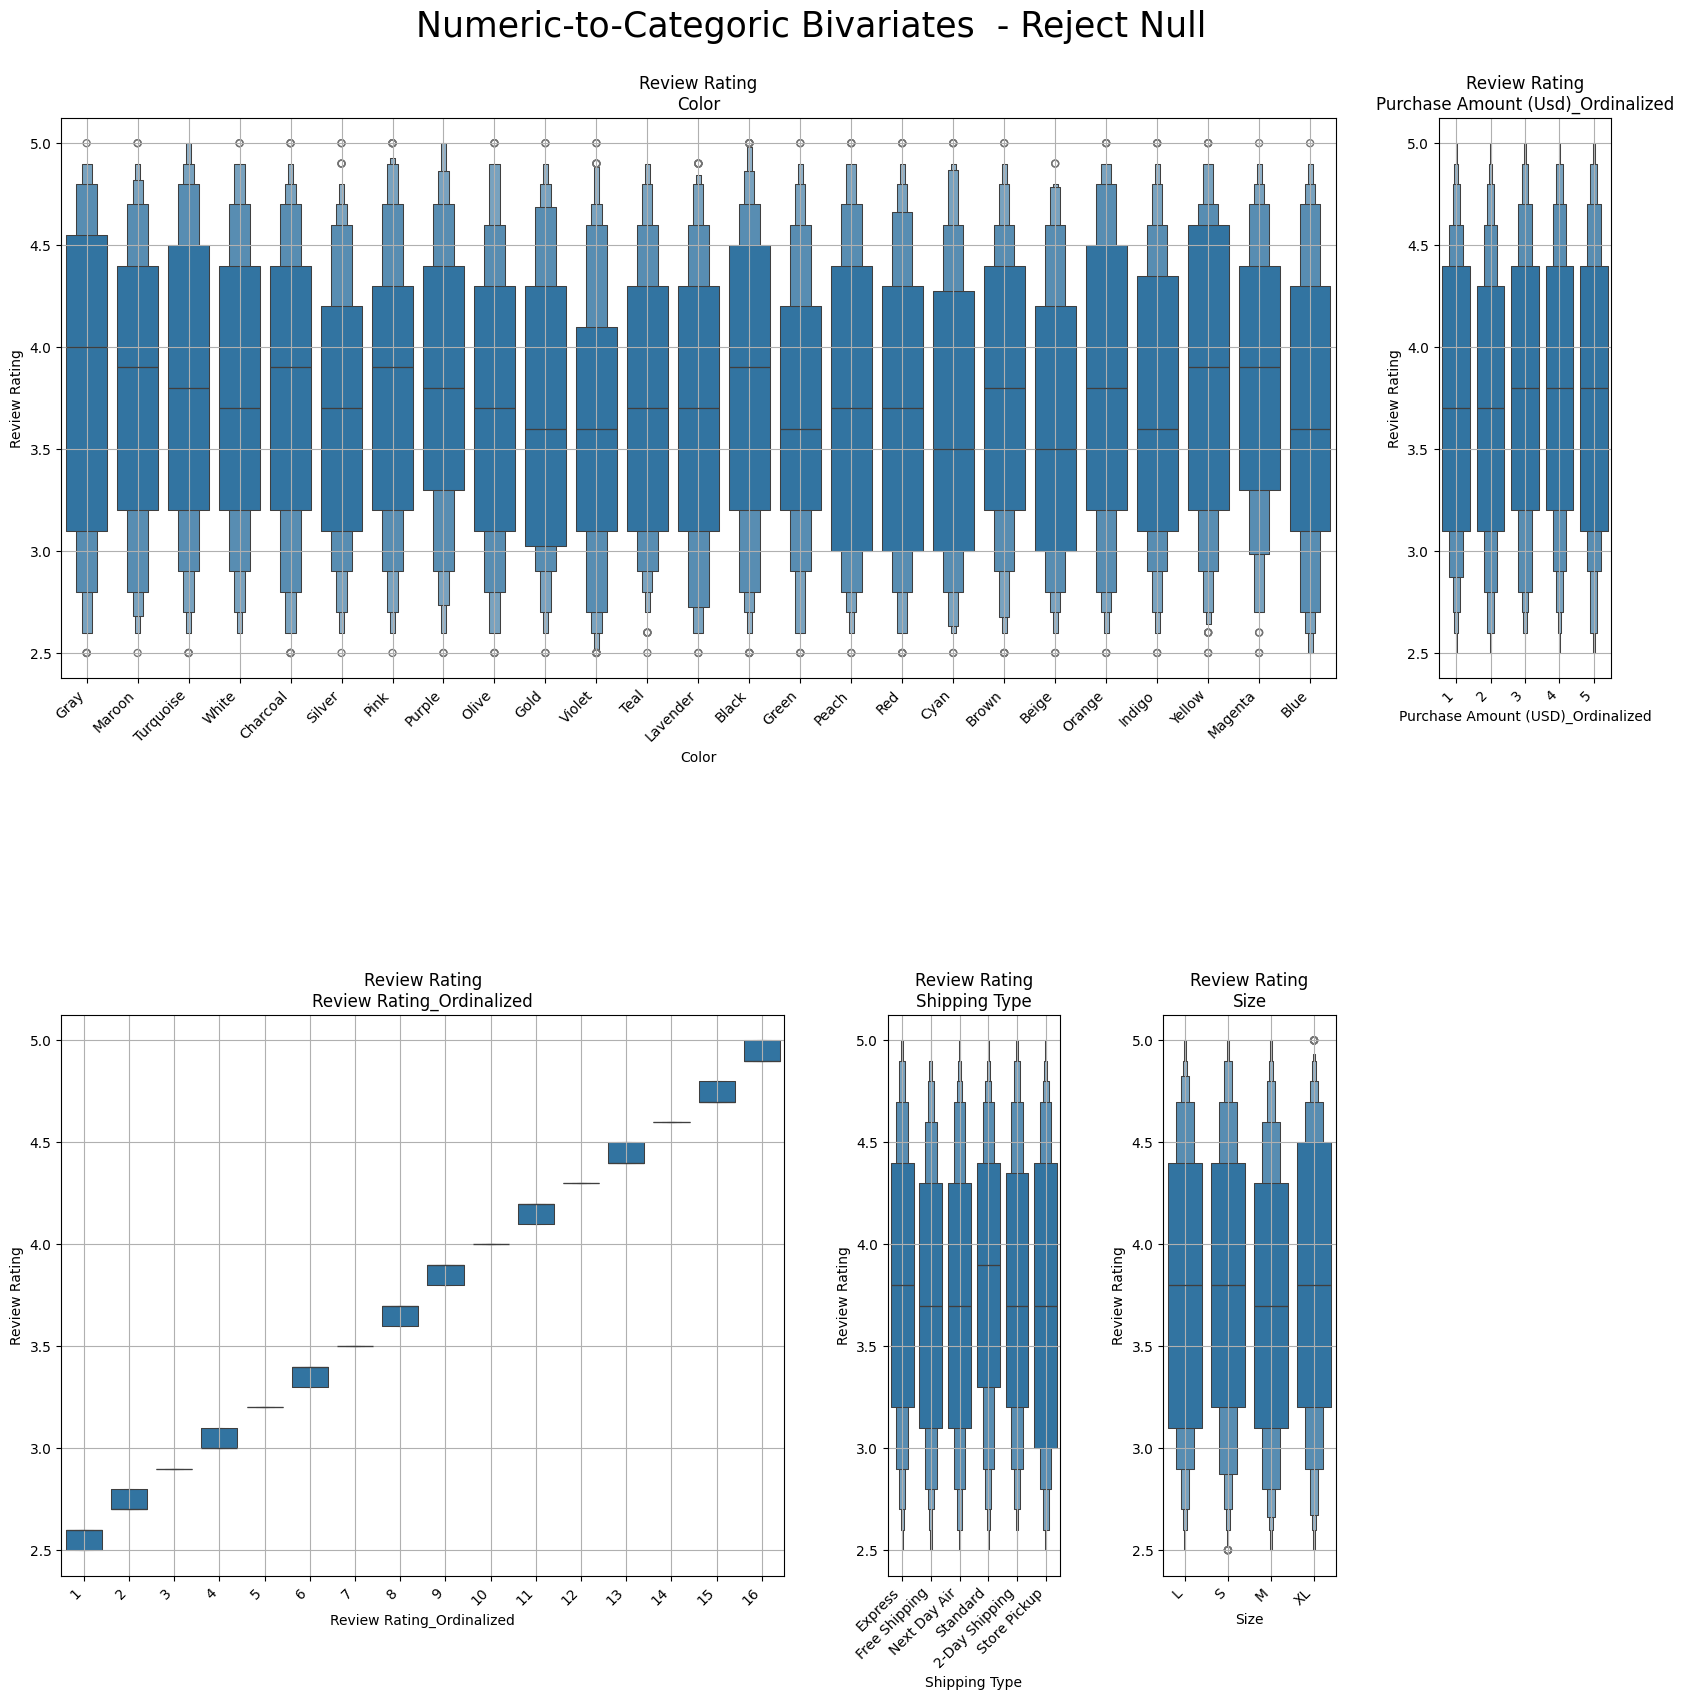

Plot Supercategory-Subcategory Partitions is set to False
= = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = = 


In [ ]:
# this one calls the other internally, but plots data based on per
AD.visualize_by_targets(
                        data=df,
                        targets='Review Rating',      # targets are input here
                        reject_numcat=True,  # WHETHER TO PLOT OR NOT
                        reject_numnum=True,
                        reject_catcat=True,
                        is_super_or_subcat=True,
                        not_uniform_or_reject_normal=True,  
                        reject_multivariates=False,        # multivariate plots are not yet supported
                        auto_fit=True,   # to call fit function(s) when needed
                        targets_share_plots=False ,  # otherwise targets are plotted individually
                        check_assumptions=True,
                        dropna_gof=True,
                        cat_univar_params = cat_univar_params,
                        catcat_bivar_params = catcat_bivar_params,
                        numnum_bivar_params = numnum_bivar_params,
                        numcat_bivar_params = numcat_bivar_params,
                        super_subcat_pairs_params = super_subcat_pairs_params,
                        num_univar_params = num_univar_params
                        )

## Histogram bin edges can be controlled such as to minimize number of bins while keeping statistical significant thresholds
## Or to exclude multivariate combinations

Pre examination of binning metrics for Total Days of Patronage show a per variable bin range of [2,556]:   
Plots vary based on using minimums, multivar, or max of min -vs- default

In [ ]:
mn,mp = AD.get_a_varaibles_binning_metrics(df,
                                        target='Total Days of Patronage',
                                        check_multivar=True)
print('='*23)
print('Total Days of Patronage')
print('Absolute min bins: ', mn)
print('Bin meta: ',mp)
print('='*23)


Total Days of Patronage
Absolute min bins:  556
Bin meta:  {'Total Days of Patronage_Binned': 2, 'Promo Code Used_|&|_Season_|&|_Size': 34, 'Frequency of Purchases': 2, 'Male_|&|_Purchase Amount (USD)_Ordinalized_|&|_Season': 56, 'Total Days of Patronage_Ordinalized': 2, 'Discount Applied_|&|_Season_|&|_Size': 34, 'Male_|&|_Season_|&|_Size': 56, 'Location_|&|_Male_|&|_Size': 197, 'Male_|&|_Review Rating_Ordinalized_|&|_Subscription Status': 68, 'Previous Purchases_Ordinalized': 2, 'Location_|&|_Male_|&|_Season': 556}


In [ ]:
pd.DataFrame({k:[v] for k,v in mp.items()})

,Total Days of Patronage_Binned,Promo Code Used_|&|_Season_|&|_Size,Frequency of Purchases,Male_|&|_Purchase Amount (USD)_Ordinalized_|&|_Season,Total Days of Patronage_Ordinalized,Discount Applied_|&|_Season_|&|_Size,Male_|&|_Season_|&|_Size,Location_|&|_Male_|&|_Size,Male_|&|_Review Rating_Ordinalized_|&|_Subscription Status,Previous Purchases_Ordinalized,Location_|&|_Male_|&|_Season
0,2,34,2,56,2,34,56,197,68,2,556


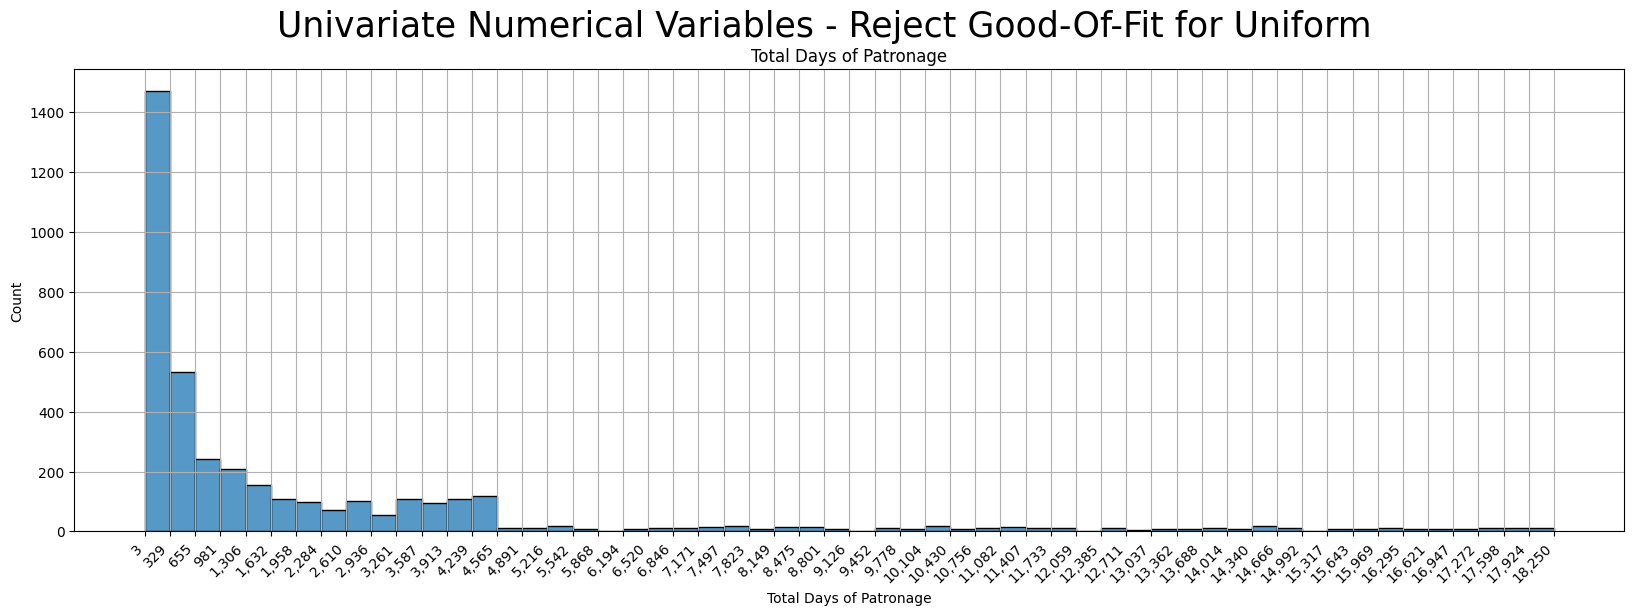

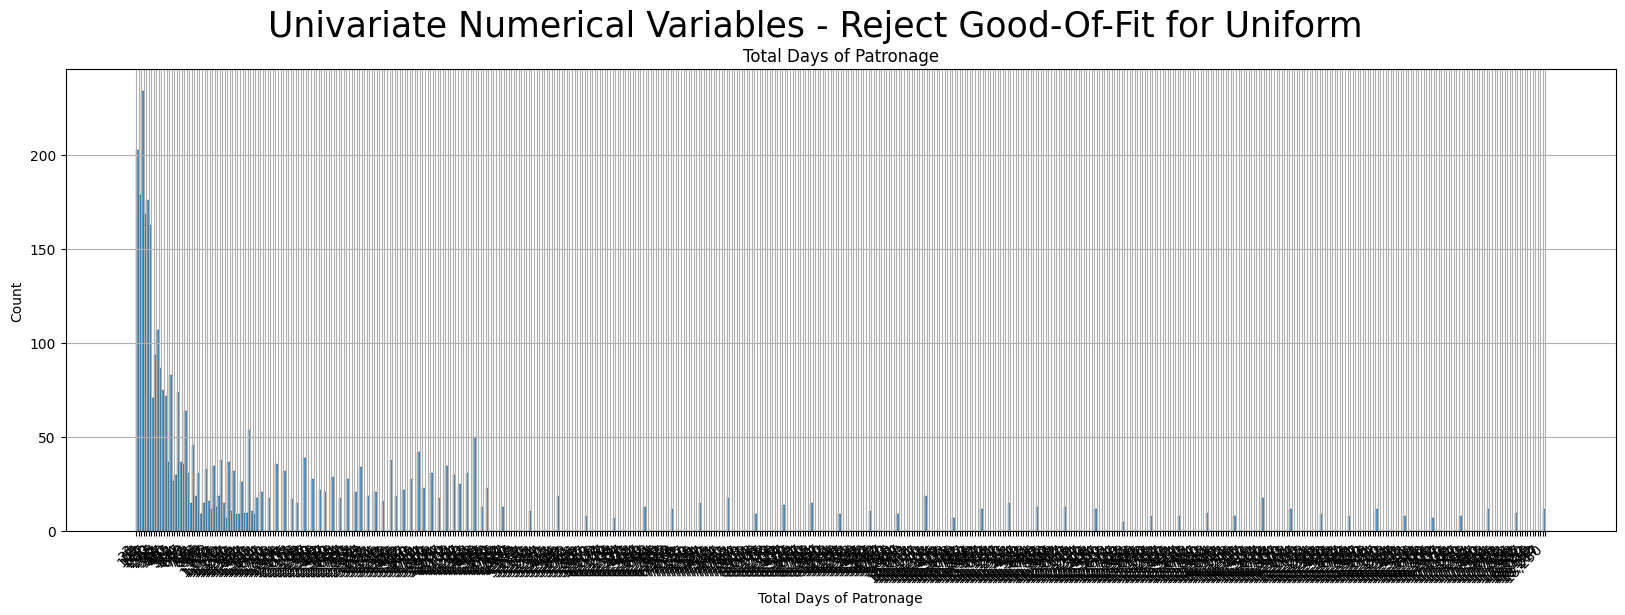

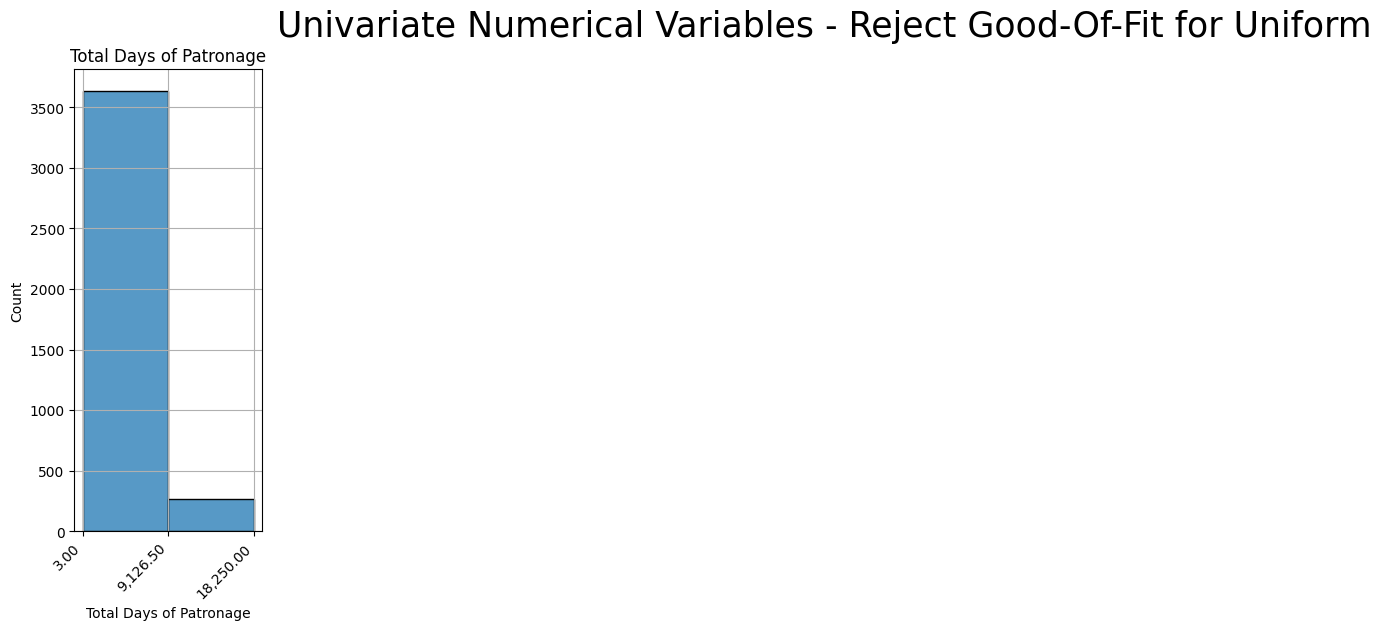

In [ ]:
AD.plot_non_normal_numeric(df,
                           numerical= ['Total Days of Patronage'])
AD.plot_non_normal_numeric(df,
                           numerical= ['Total Days of Patronage'],
                            force_significant_bin_edges=True,
                            minimize_significant_bins=True,
                            include_multivariate=True)
AD.plot_non_normal_numeric(df,
                           numerical= ['Total Days of Patronage'],
                            force_significant_bin_edges=True,
                            minimize_significant_bins=True,
                            include_multivariate=False)

# Produce all significant plots in one shot

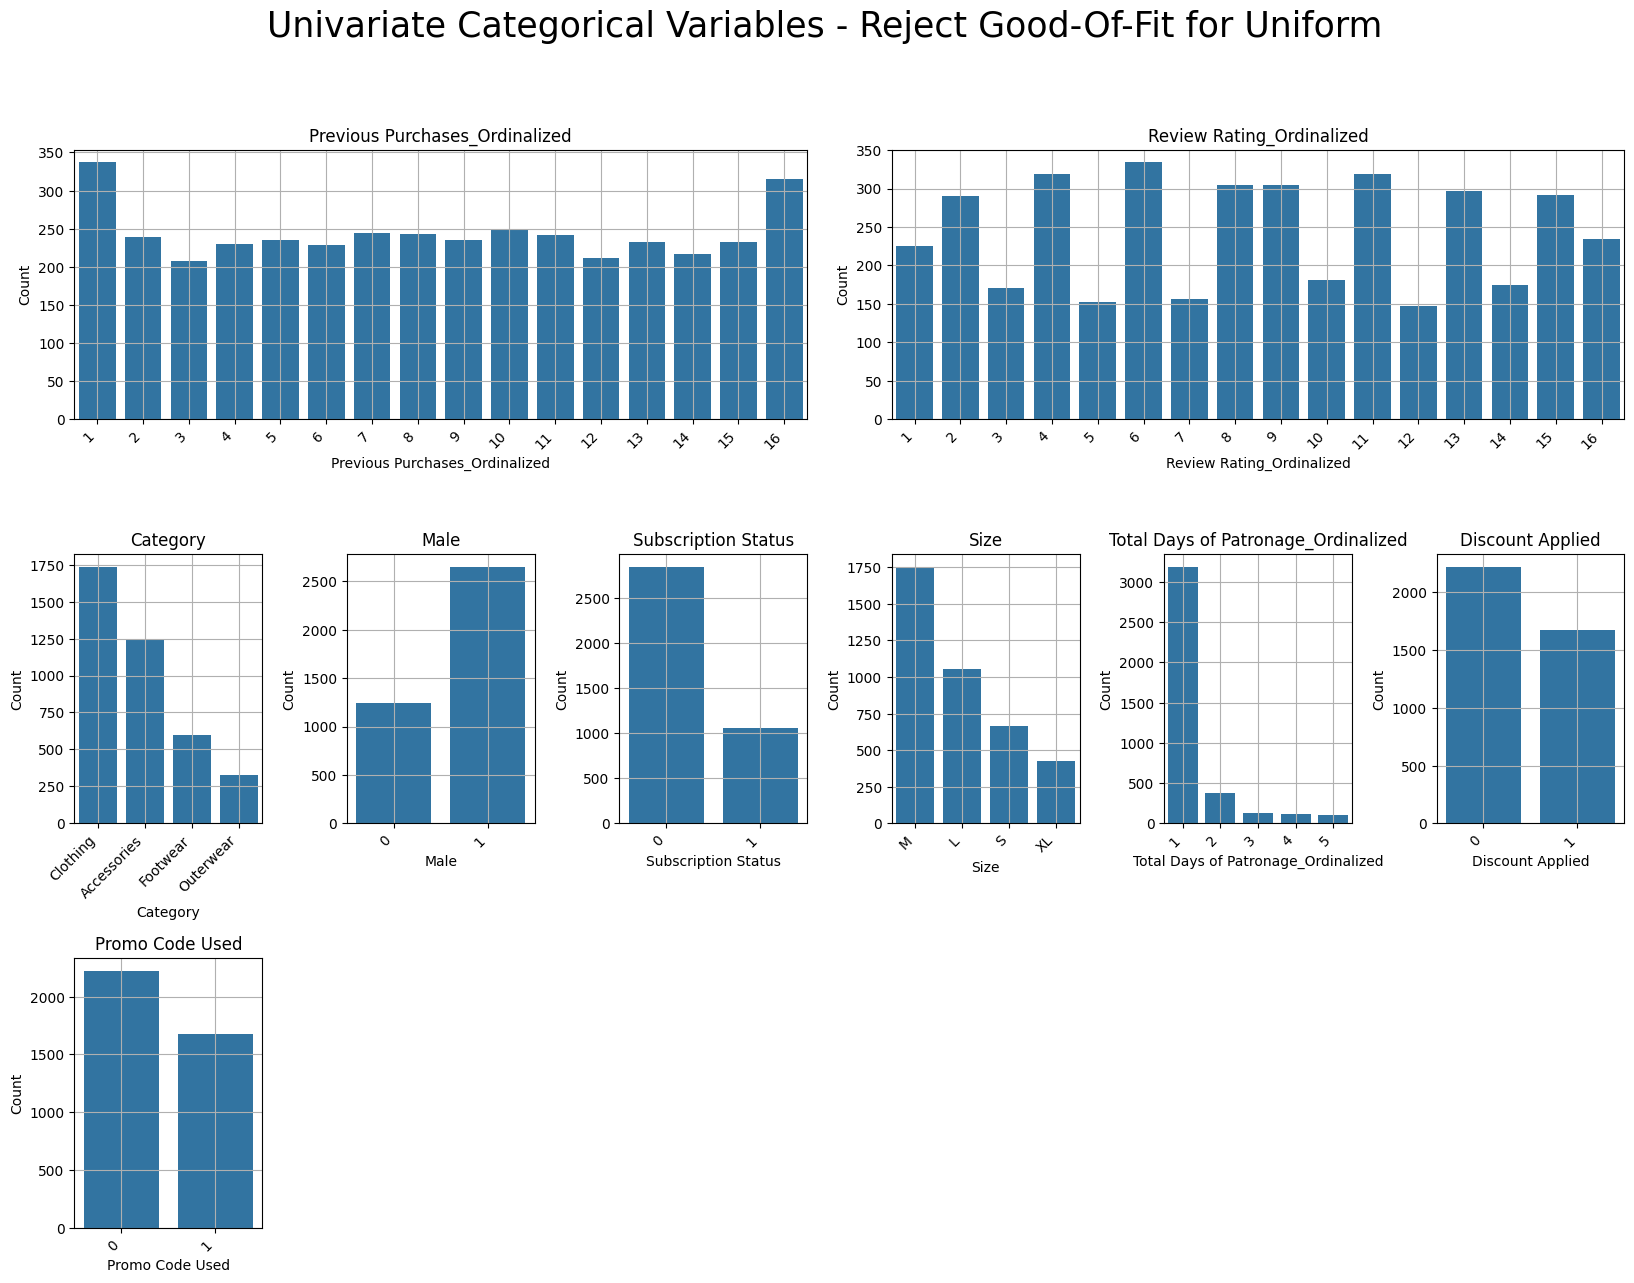

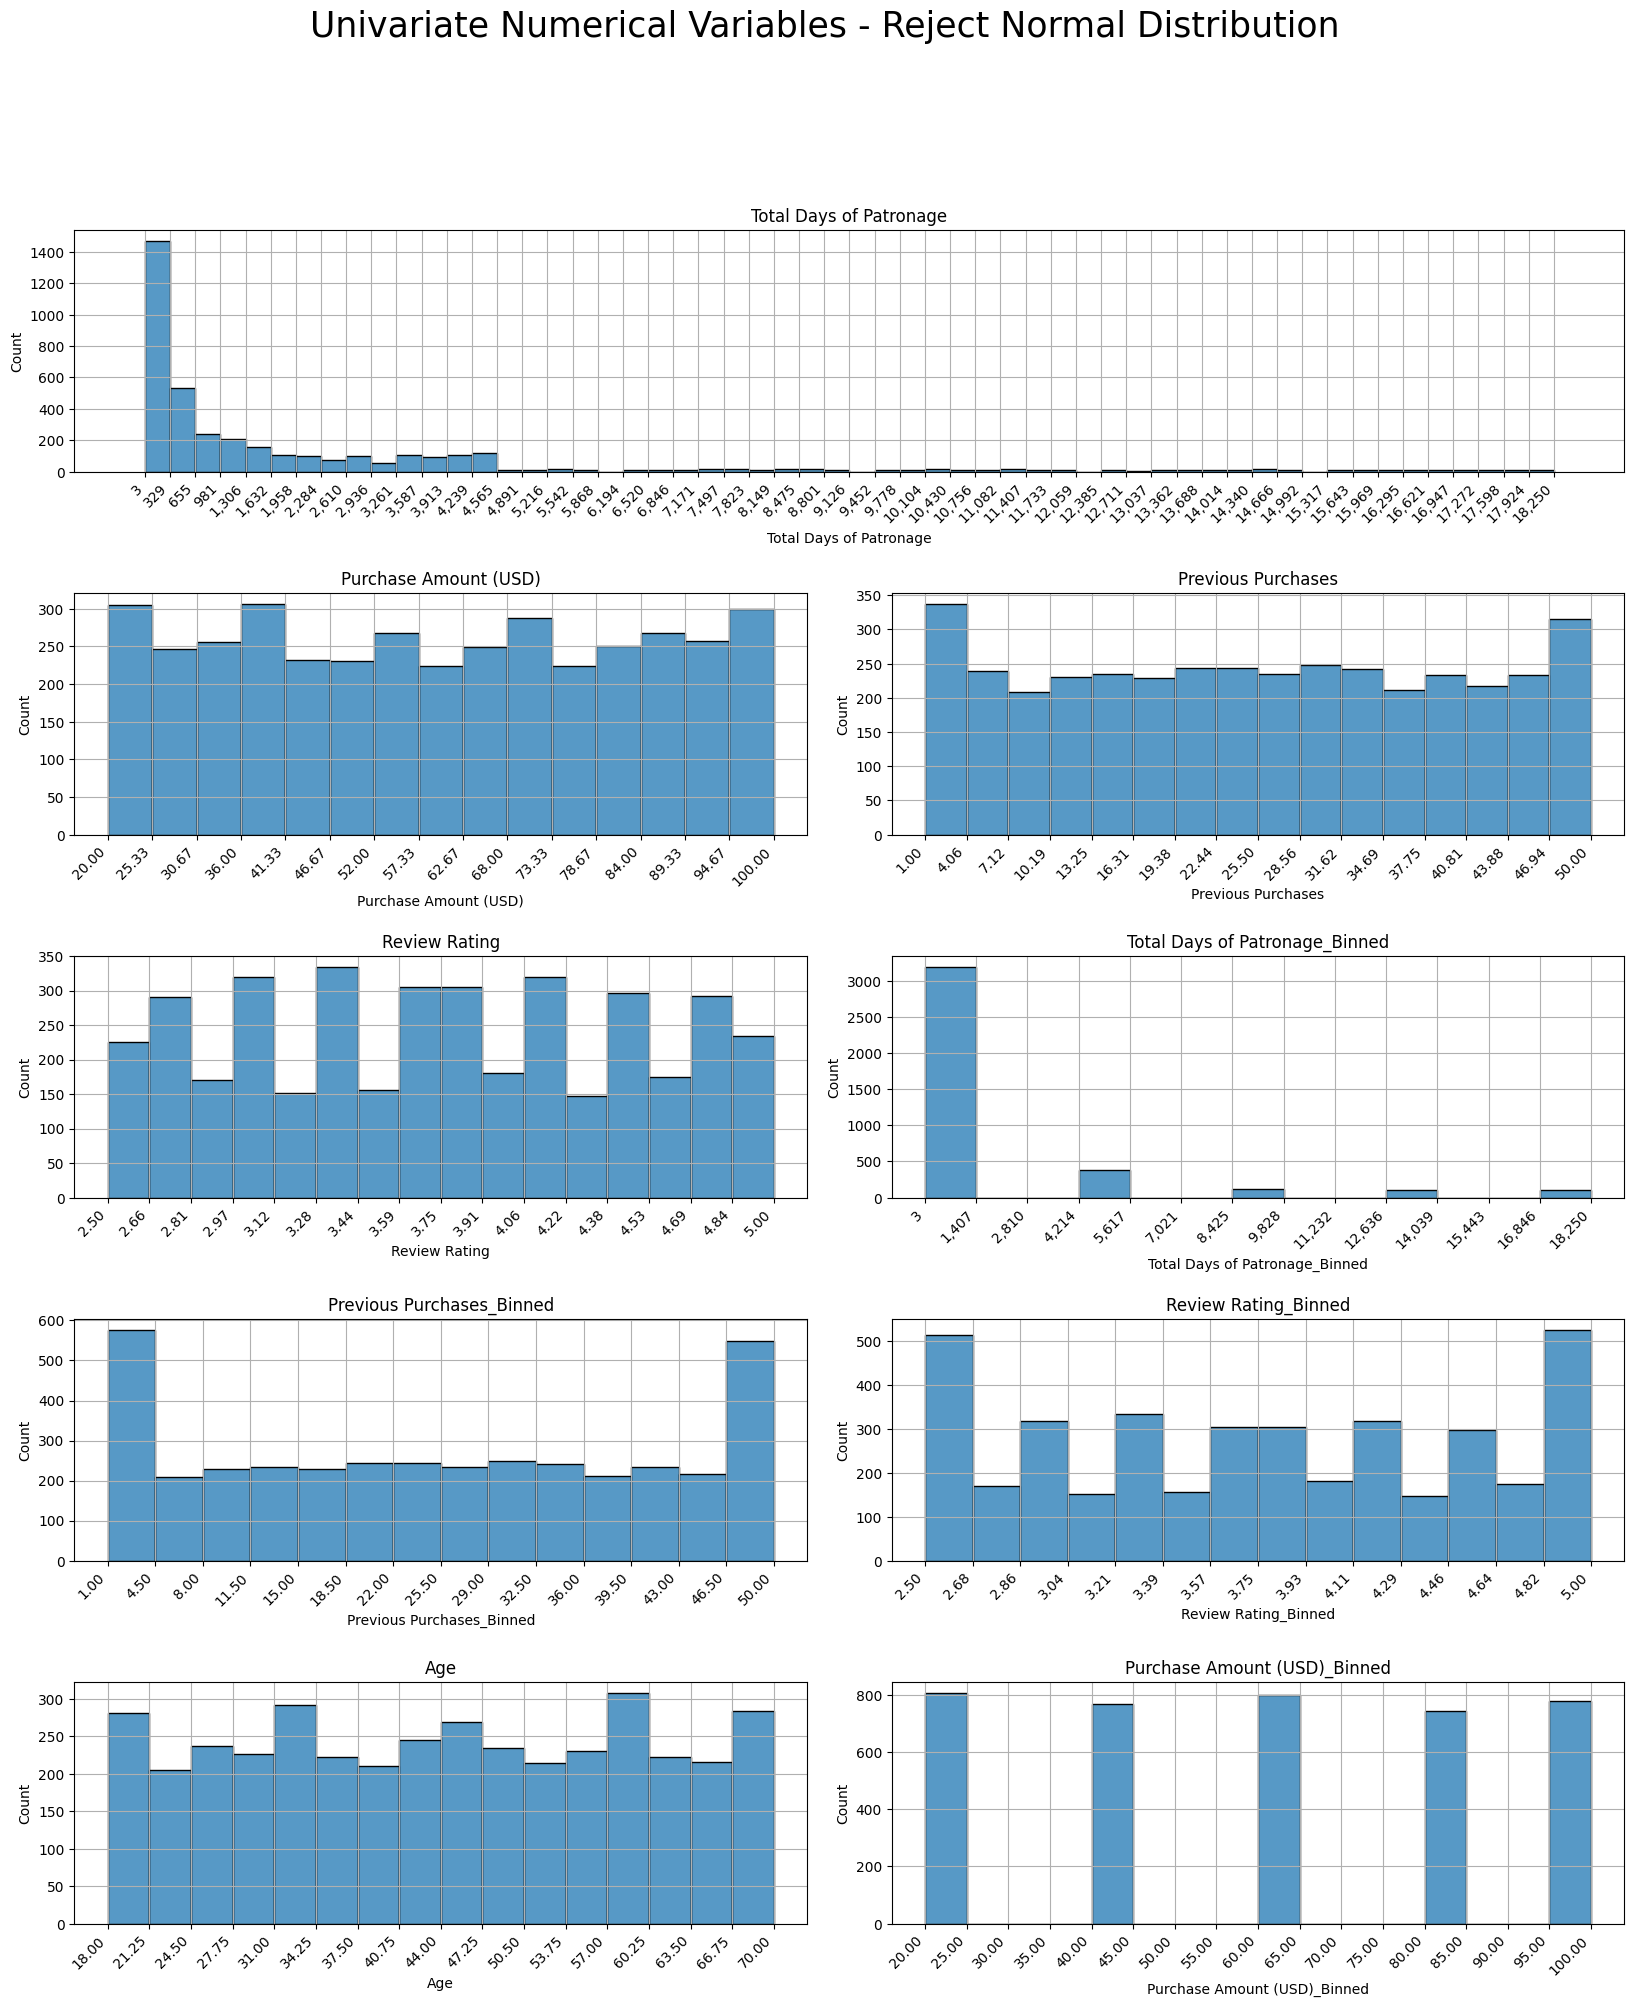

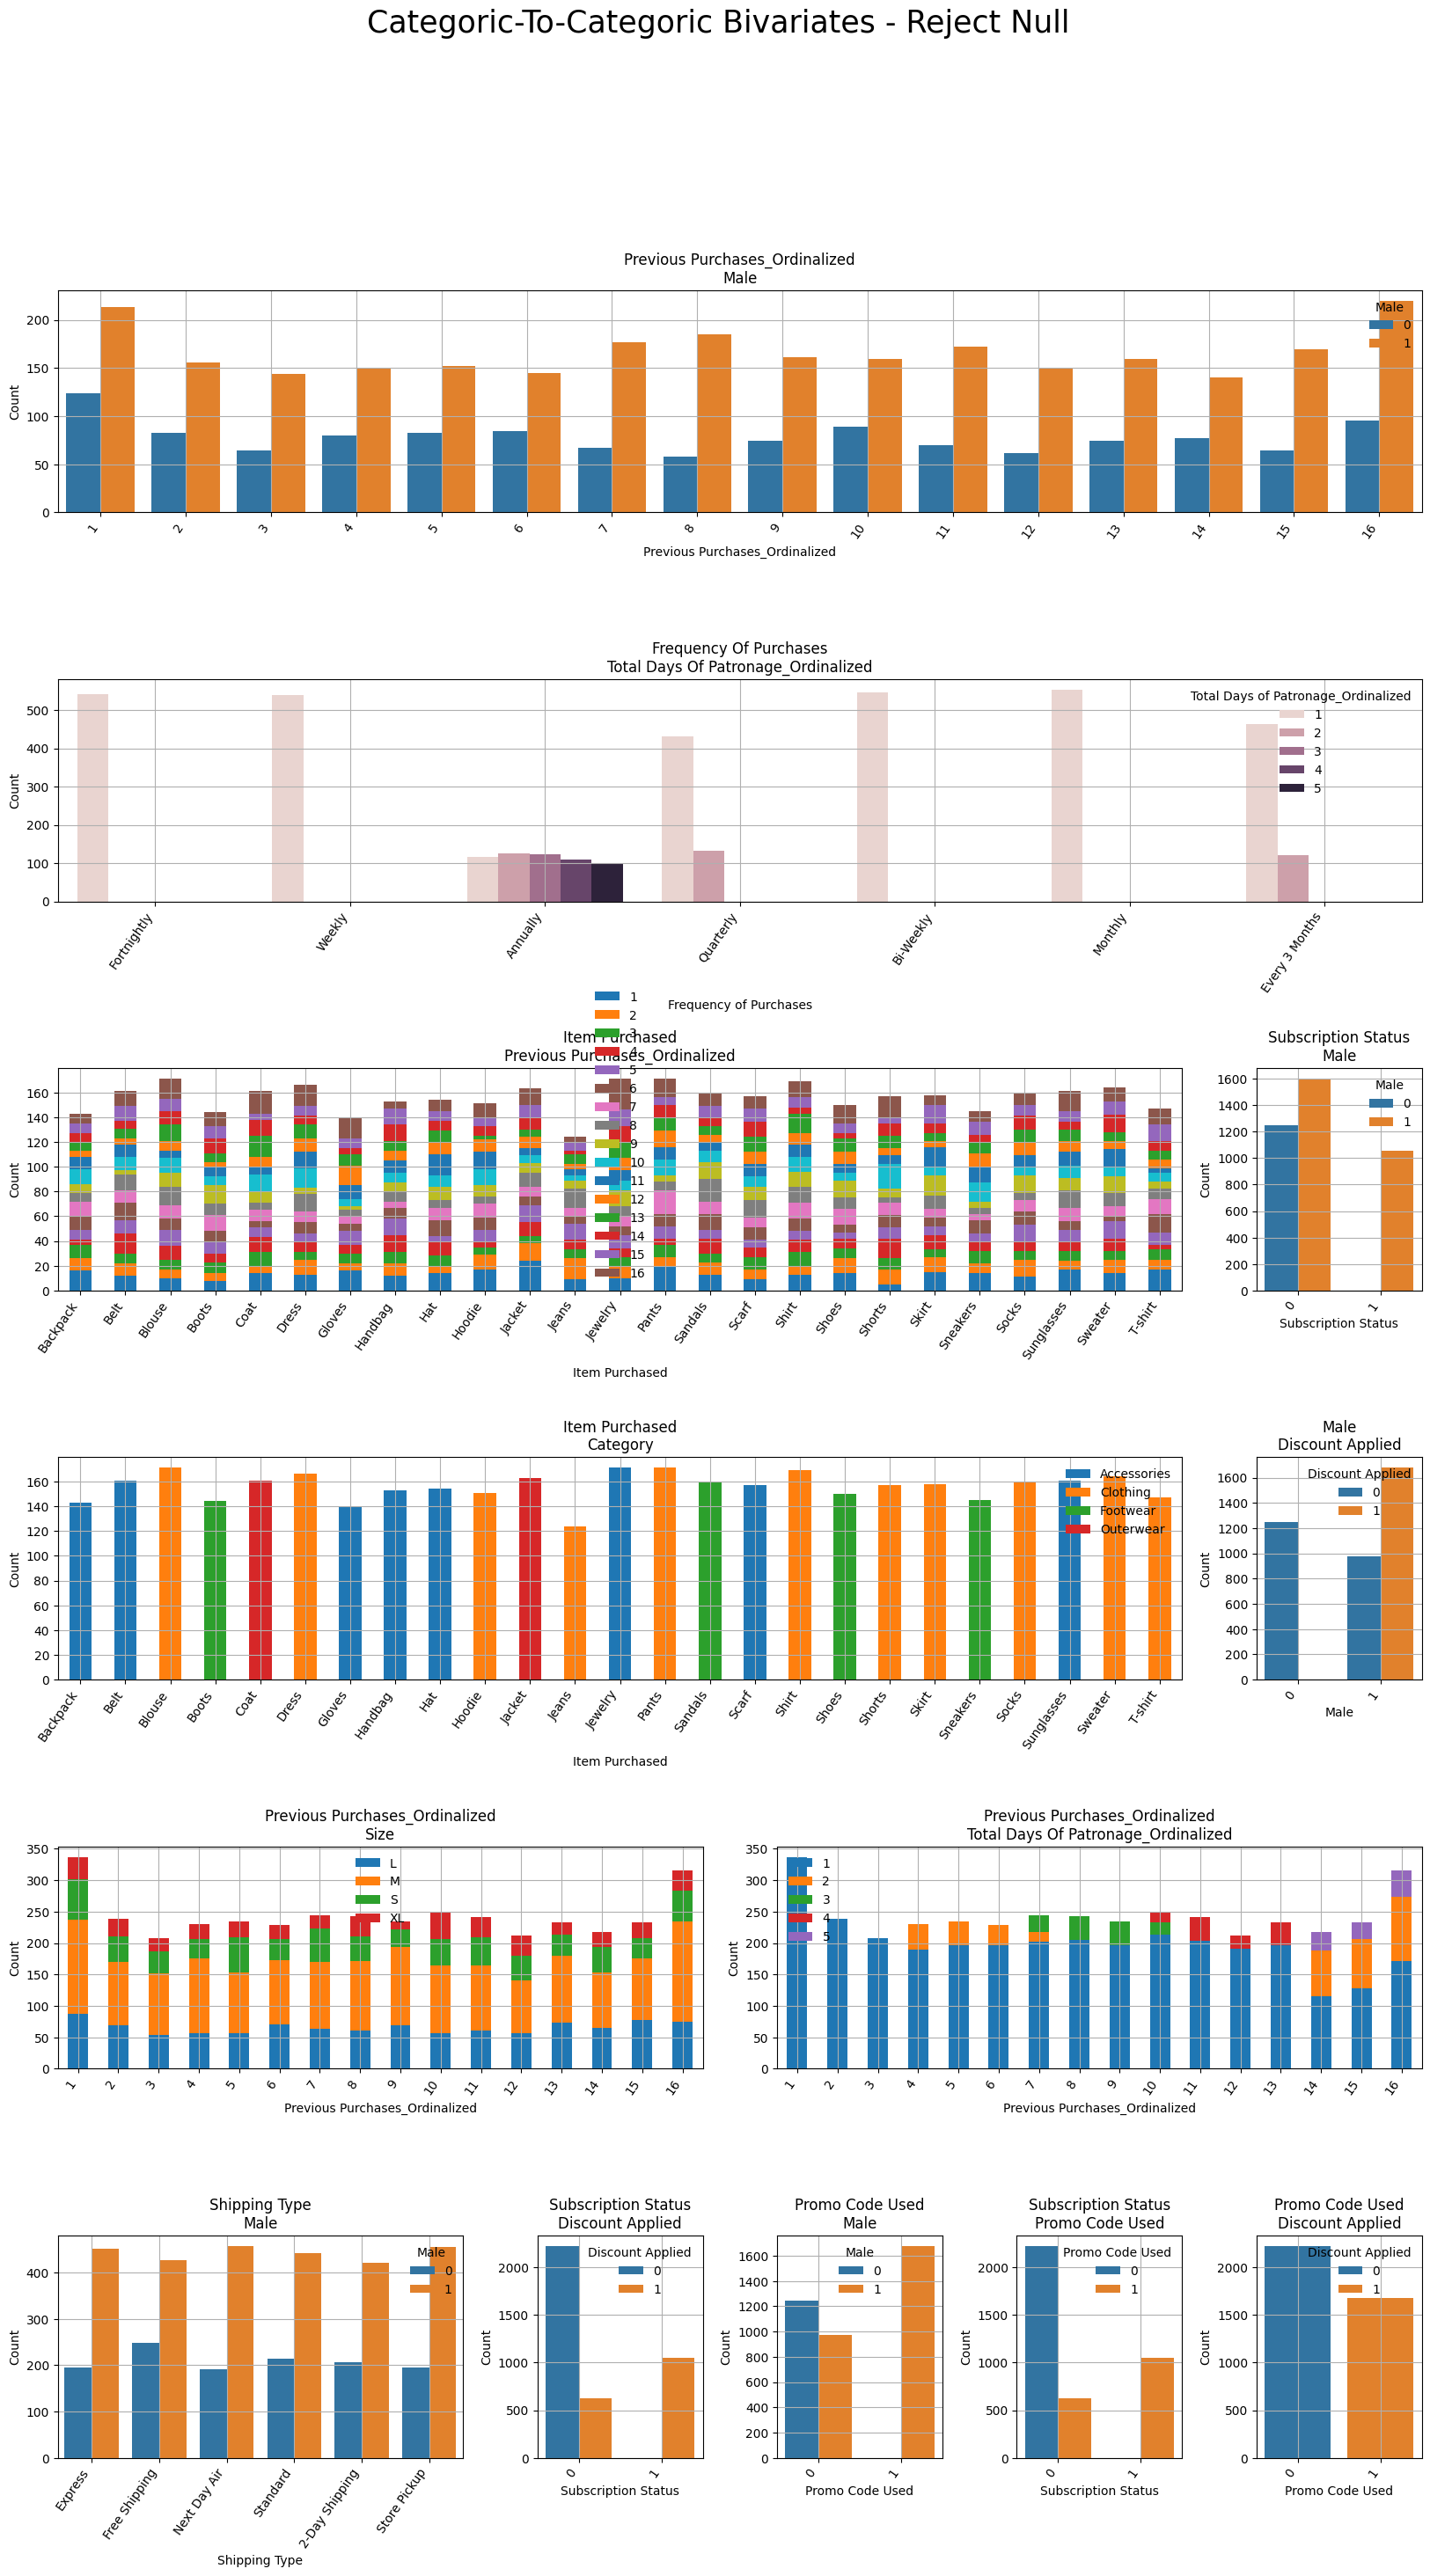

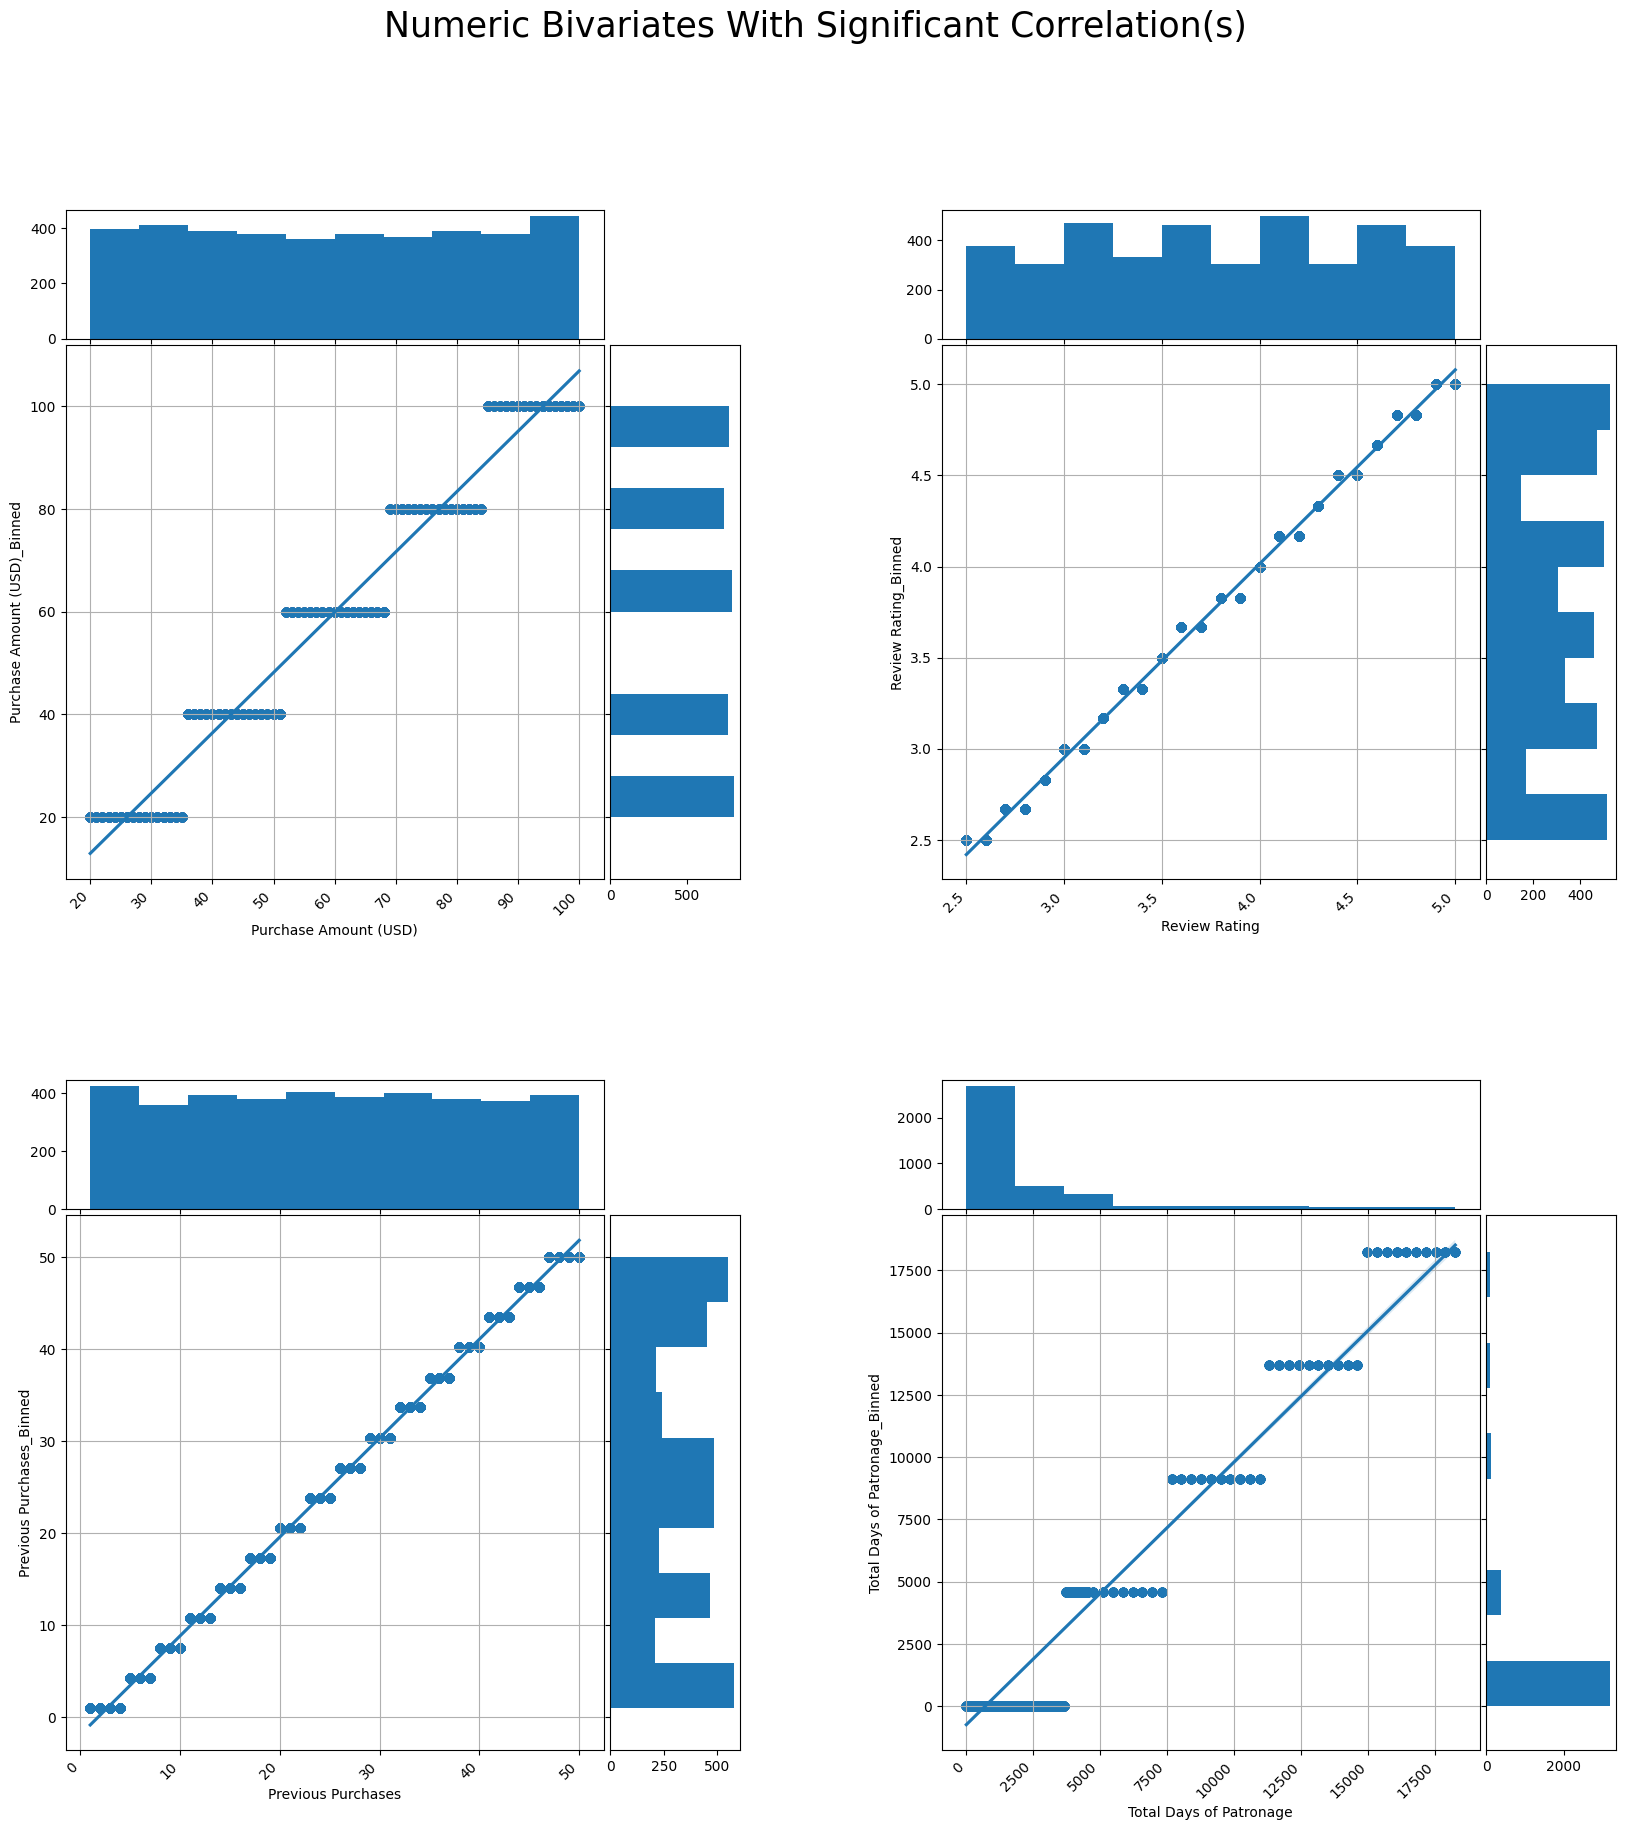

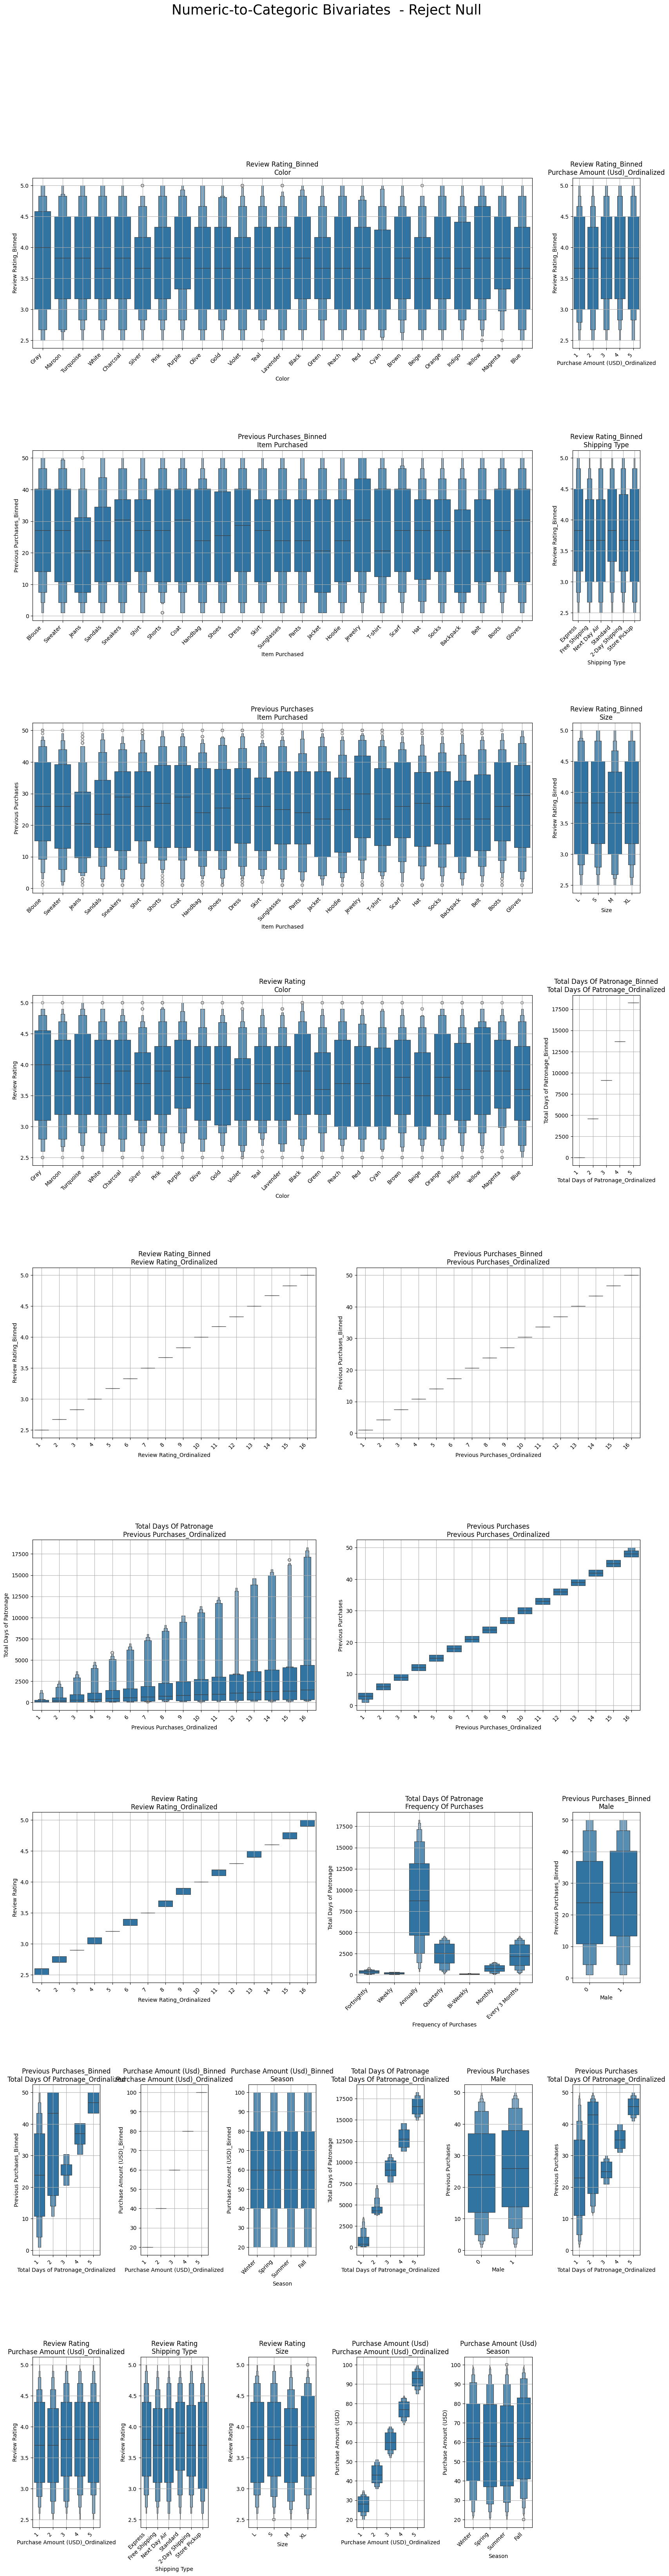

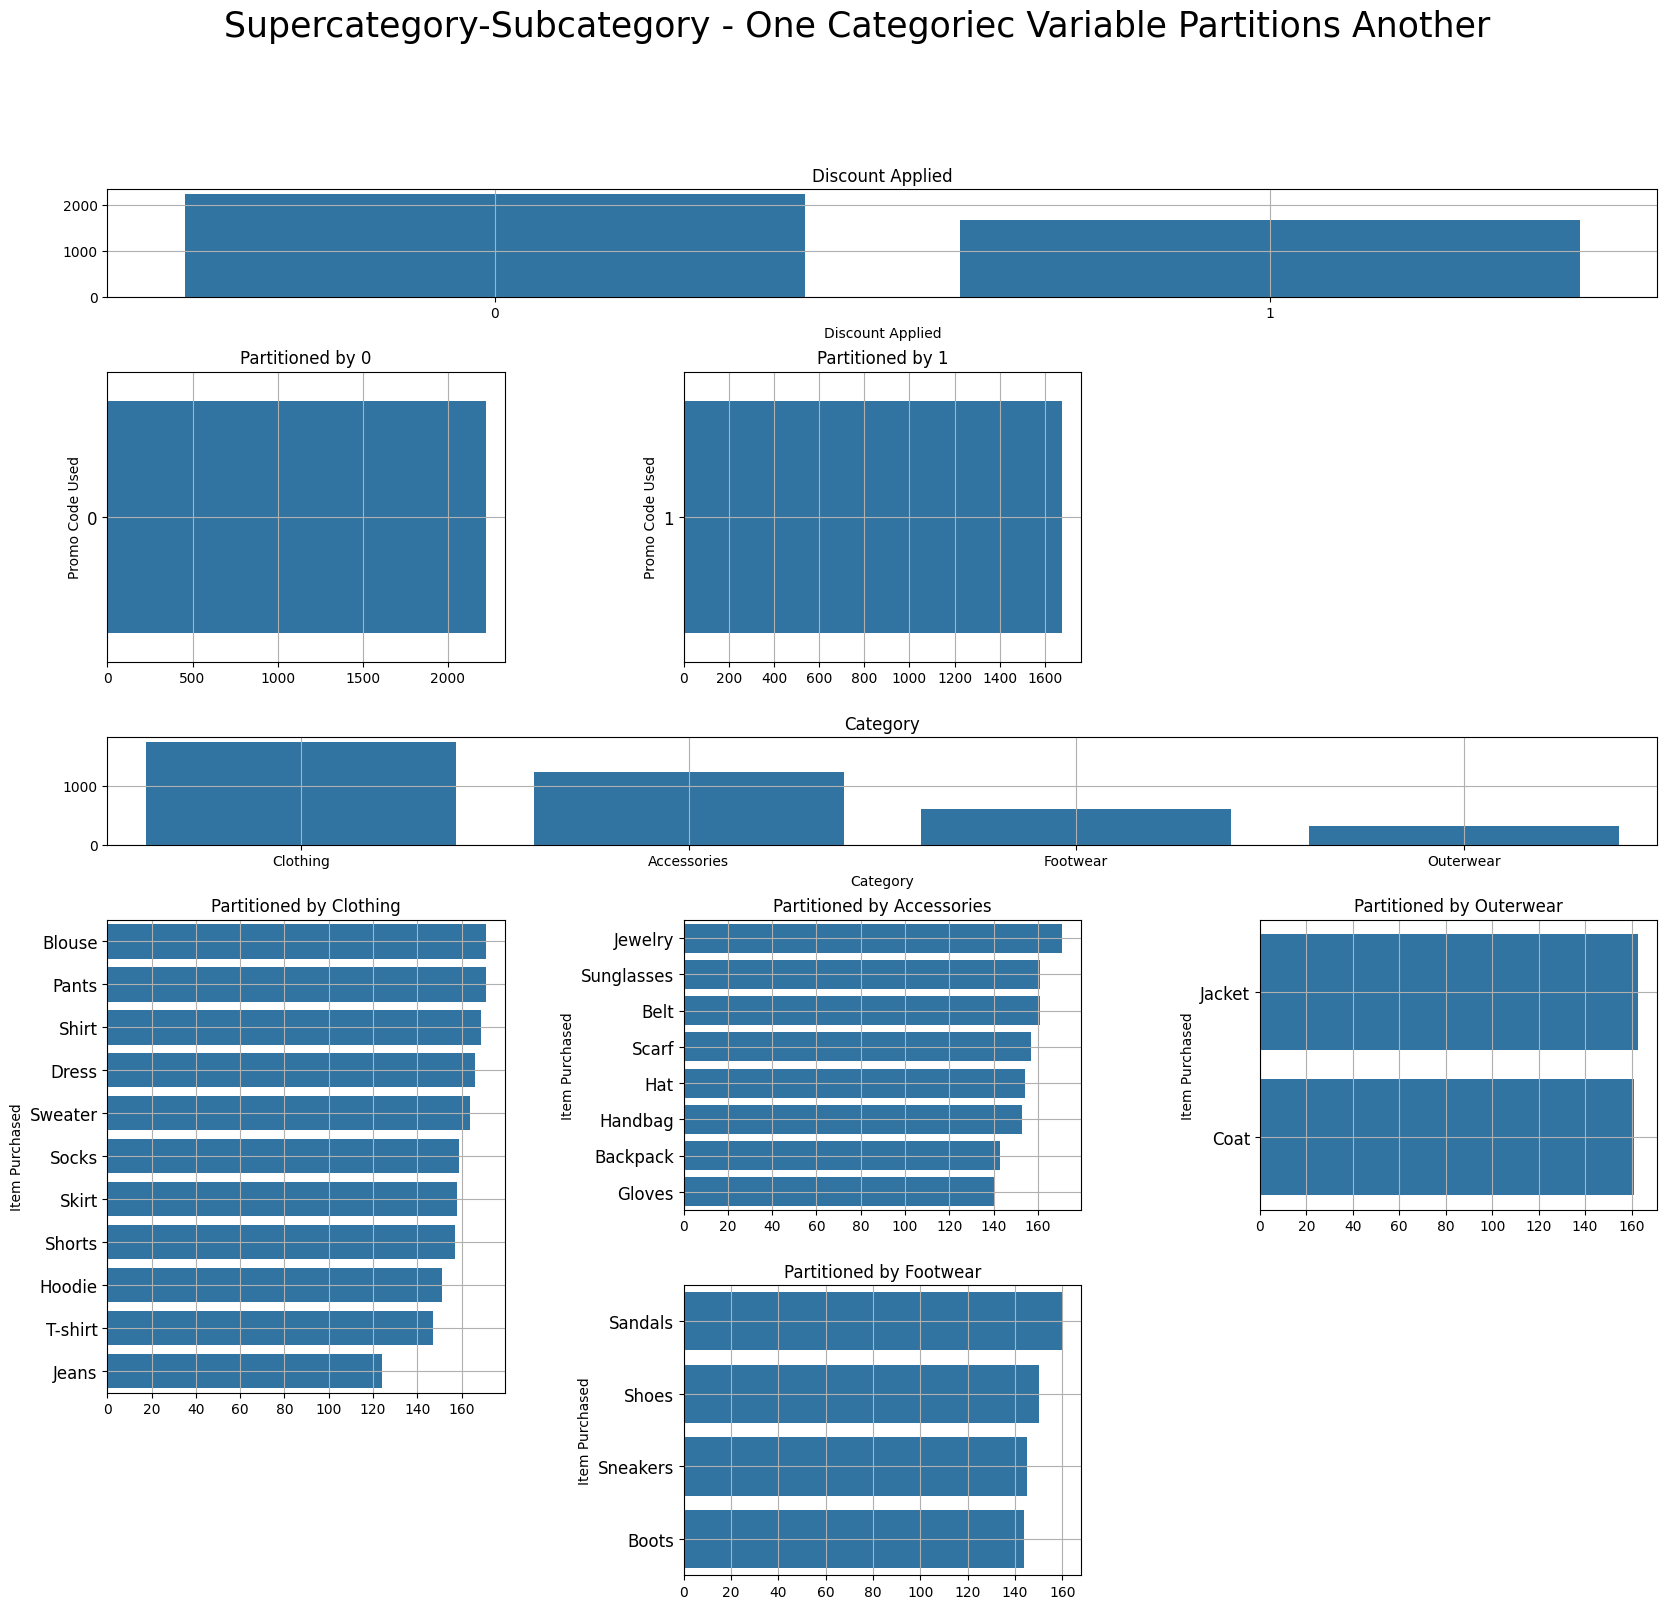

In [ ]:
AD.produce_all_plots(df)